In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

In [15]:
# Load preprocessed data
df = pd.read_csv("../data/processed/cs-processed.csv")

print(f"Rows: {len(df)}")
print(f"Target distribution: {df['SeriousDlqin2yrs'].value_counts(normalize=True).round(3)}")
print(f"Missing values:{df.isnull().sum()[df.isnull().sum() > 0]}")

Rows: 146678
Target distribution: SeriousDlqin2yrs
0    0.94
1    0.06
Name: proportion, dtype: float64
Missing values:Series([], dtype: int64)


In [4]:
# Define features and target
FEATURE_COLS = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents",
]

X = df[FEATURE_COLS]
y = df["SeriousDlqin2yrs"]

In [5]:
# Train/test split - stratified to preserve class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training rows: {len(X_train)} | Test rows: {len(X_test)}")
print(f"Test set default rate: {y_test.mean():.3f}")

Training rows: 117342 | Test rows: 29336
Test set default rate: 0.060


In [6]:
# Scale features - logistic regression is sensitive to feature scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Train a simple logistic regression baseline with no class weighting
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)
model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [8]:
# Overall evaluation
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("=== Overall Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))

=== Overall Performance ===
Accuracy: 0.940
ROC-AUC:  0.798

              precision    recall  f1-score   support

  No Default       0.94      1.00      0.97     27578
     Default       0.49      0.04      0.07      1758

    accuracy                           0.94     29336
   macro avg       0.72      0.52      0.52     29336
weighted avg       0.91      0.94      0.92     29336



In [16]:
# Reconstruct the test set with predictions
test_df = X_test.copy()
test_df["true_label"] = y_test.values
test_df["predicted_label"] = y_pred
test_df["predicted_prob"] = y_prob

In [18]:
# Define age groups
def assign_age_group(age):
    if age < 35:
        return "Under 35"
    elif age <= 60:
        return "35-60"
    else:
        return "Over 60"

test_df["age_group"] = test_df["age"].apply(assign_age_group)

print("Age group sizes:")
print(test_df["age_group"].value_counts())

def group_metrics(group_df):
    """Compute key fairness-relevant metrics for a subset of the test data"""
    true = group_df["true_label"]
    predicted = group_df["predicted_label"]

    tn, fp, fn, tp = confusion_matrix(true, predicted, labels=[0, 1]).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    predicted_default_rate = predicted.mean() # proportion predicted as default (1)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0 # false positive rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0 # false negative rate

    return {
        "n": len(group_df),
        "default_rate": true.mean().round(3),
        "accuracy": round(accuracy, 3),
        "predicted_default_rate": round(predicted_default_rate, 3),
        "false_positive_rate": round(fpr, 3),
        "false_negative_rate": round(fnr, 3),
    }

results = {}
for group in ["Under 35", "35-60", "Over 60"]:
    subset = test_df[test_df["age_group"] == group]
    results[group] = group_metrics(subset)

metrics_df = pd.DataFrame(results).T
print("=== Group-Level Metrics ===")
print(metrics_df.to_string())

Age group sizes:
age_group
35-60       16635
Over 60      9039
Under 35     3662
Name: count, dtype: int64
=== Group-Level Metrics ===
                n  default_rate  accuracy  predicted_default_rate  false_positive_rate  false_negative_rate
Under 35   3662.0         0.102     0.897                   0.016                0.009                0.928
35-60     16635.0         0.069     0.931                   0.005                0.002                0.967
Over 60    9039.0         0.027     0.973                   0.000                0.000                0.996


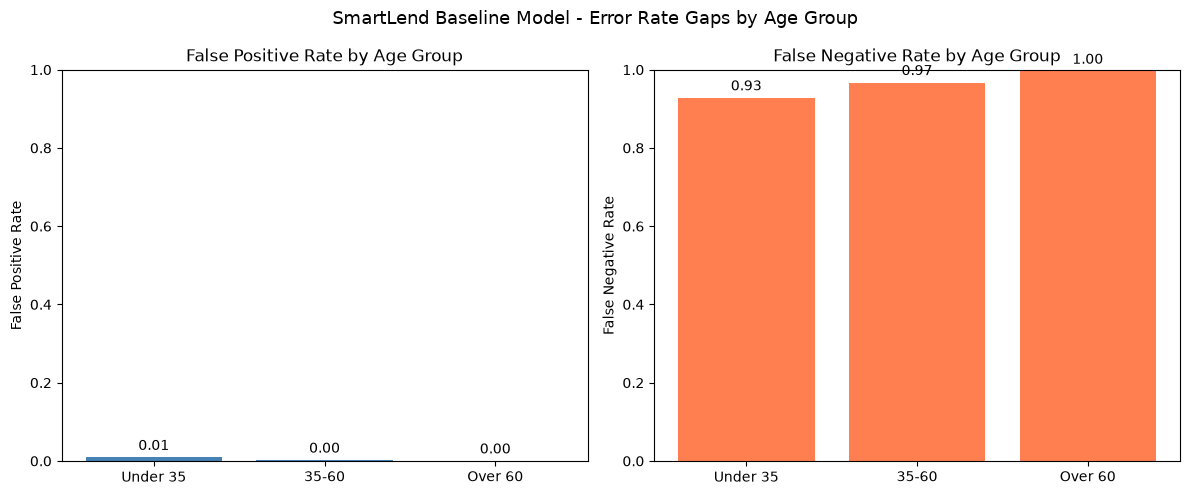

Chart saved to docs/fairness_fpr_fnr_by_age.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

groups = metrics_df.index.tolist()
x = range(len(groups))

axes[0].bar(x, metrics_df["false_positive_rate"], color="steelblue")
axes[0].set_xticks(x)
axes[0].set_xticklabels(groups)
axes[0].set_title("False Positive Rate by Age Group")
axes[0].set_ylabel("False Positive Rate")
axes[0].set_ylim(0, 1)
axes[0].bar_label(axes[0].containers[0], fmt="%.2f", padding=3)

axes[1].bar(x, metrics_df["false_negative_rate"], color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(groups)
axes[1].set_title("False Negative Rate by Age Group")
axes[1].set_ylabel("False Negative Rate")
axes[1].set_ylim(0, 1)
axes[1].bar_label(axes[1].containers[0], fmt="%.2f", padding=3)

plt.suptitle("SmartLend Baseline Model - Error Rate Gaps by Age Group", fontsize=13)
plt.tight_layout()
plt.savefig("../docs/fairness_fpr_fnr_by_age.png", dpi=150)
plt.show()

print("Chart saved to docs/fairness_fpr_fnr_by_age.png")

In [ ]:
# Compute demographic parity-style gap (predicted default rate disparity)
predicted_default_rates = metrics_df["predicted_default_rate"]
dp_gap = predicted_default_rates.max() - predicted_default_rates.min()

In [24]:
# Compute false positive rate gap
fpr_values = metrics_df["false_positive_rate"]
fpr_gap = fpr_values.max() - fpr_values.min()

In [25]:
# Compute false negative rate gap
fnr_values = metrics_df["false_negative_rate"]
fnr_gap = fnr_values.max() - fnr_values.min()

In [ ]:
print("=== Fairness Gaps ===")
print(f"Predicted Default Rate Gap:               {dp_gap:.3f}")
print(f"False Positive Rate Gap:                  {fpr_gap:.3f}")
print(f"FNR Gap (false negative rate):               {fnr_gap:.3f}")
print()
print("Predicted default rates by group:")
print(predicted_default_rates)
print()
print("FPR by group:")
print(fpr_values)
print()
print("FNR by group:")
print(fnr_values)

"""U35s have the highest FPR so are being incorrectly flagged as default risks at a higher rate than others
O60s have the highest FNR so are being incorrectly flagged as non-default risks at a higher rate than others"""

=== Fairness Gaps ===
Predicted Default Rate Gap:               0.016
False Positive Rate Gap:                  0.009
FNR Gap (false negative rate):               0.068

Predicted default rates by group:
Under 35    0.016
35-60       0.005
Over 60     0.000
Name: predicted_default_rate, dtype: float64

FPR by group:
Under 35    0.009
35-60       0.002
Over 60     0.000
Name: false_positive_rate, dtype: float64

FNR by group:
Under 35    0.928
35-60       0.967
Over 60     0.996
Name: false_negative_rate, dtype: float64


In [28]:
# Try a higher threshold for the group with the highest FPR
high_fpr_group = fpr_values.idxmax()
adjusted_threshold = 0.6  # Experiment with this value

test_df["adjusted_label"] = test_df["predicted_prob"].apply(
    lambda p: 1 if p >= 0.5 else 0
)

In [29]:
# Apply higher threshold only to the high-FPR group
mask = test_df["age_group"] == high_fpr_group
test_df.loc[mask, "adjusted_label"] = test_df.loc[mask, "predicted_prob"].apply(
    lambda p: 1 if p >= adjusted_threshold else 0
)

In [33]:
# Re-evaluate group metrics with adjusted predictions
print(f"=== After threshold adjustment for {high_fpr_group} ===")
for group in ["Under 35", "35-60", "Over 60"]:
    subset = test_df[test_df["age_group"] == group].copy()
    subset["predicted_label"] = subset["adjusted_label"]
    m = group_metrics(subset)
    print(f"{group}: FPR={m['false_positive_rate']}, FNR={m['false_negative_rate']}")

=== After threshold adjustment for Under 35 ===
Under 35: FPR=0.008, FNR=0.944
35-60: FPR=0.002, FNR=0.967
Over 60: FPR=0.0, FNR=0.996
